In [13]:
import os
import joblib
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, TargetEncoder, OrdinalEncoder,
    StandardScaler, RobustScaler,
    FunctionTransformer
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

file_path = os.path.join(
    os.path.dirname(os.path.abspath(os.getcwd())),
    "data", "employee_satisfaction.csv"
)

df = pd.read_csv(file_path)

In [14]:
numeric_cols = list(df.drop(["ID_Employe", "Satisfait"], axis=1).select_dtypes(include=["number"]).columns)
category_cols = list(df.drop(["ID_Employe", "Satisfait"], axis=1).select_dtypes(include=["object", "str"]).columns)

### Traitement de valeurs maquantes

Heures_Supplementaires 25
Nombre_Absences 25
Sexe 25
Departement 25
Annees_Experience 25
Niveau_Etudes 25
Salaire_Mensuel_BIF 25
Travail_A_Distance 25
Age 25
Heures_Formation 25
Anciennete_Entreprise 25
Nombre_Promotions 25
Evaluation_Performance 25
Equilibre_Vie_Travail 25
Satisfaction_Salaire 25


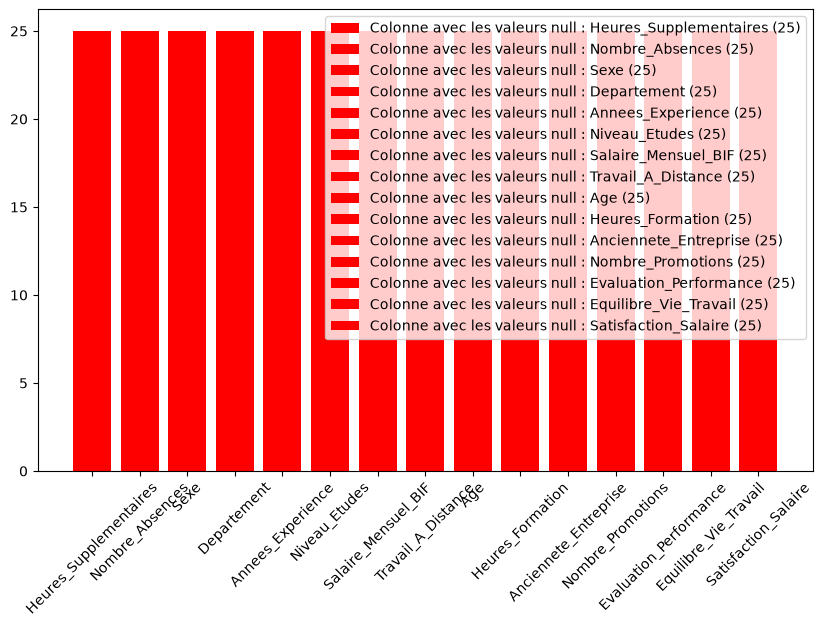

In [15]:
empty_values = df.isnull().sum().sort_values(ascending=False)
cols_with_empty_values = empty_values[empty_values > 0]

plt.figure(figsize=(10, 6))

if len(cols_with_empty_values) > 0:
    for i, _ in enumerate(cols_with_empty_values):
        col_name = cols_with_empty_values.index[i]
        col_value = cols_with_empty_values.values[i]
    
        print(col_name, col_value)
        
        label = f"Colonne avec les valeurs null : {col_name} ({col_value})"
        plt.bar(cols_with_empty_values.index, cols_with_empty_values.values, color="r", label=label)
else:
    label = "Pas de colonnes avec de valeurs nulles"
    plt.bar(cols_with_empty_values.index, cols_with_empty_values.values, color="r", label=label)

plt.legend()
plt.xticks(rotation=45)
plt.show()

In [16]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in category_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

ID_Employe                0
Age                       0
Sexe                      0
Departement               0
Annees_Experience         0
Niveau_Etudes             0
Salaire_Mensuel_BIF       0
Travail_A_Distance        0
Heures_Supplementaires    0
Heures_Formation          0
Anciennete_Entreprise     0
Nombre_Promotions         0
Evaluation_Performance    0
Equilibre_Vie_Travail     0
Satisfaction_Salaire      0
Nombre_Absences           0
Satisfait                 0
dtype: int64

### Lignes en double et Catégories incohérentes

In [65]:
# df.duplicated()
df.duplicated().sum()

np.int64(0)

In [17]:
for col in category_cols:
    print(f"{col} --> {df[col].dropna().unique()}")

Sexe --> <ArrowStringArray>
['Homme', 'Femme']
Length: 2, dtype: str
Departement --> <ArrowStringArray>
[                 'Marketing',             'Administration',
                 'Production',                 'Commercial',
        'Ressources Humaines',             'Support Client',
               'Informatique',                    'Finance',
 'Recherche et Développement',                 'Logistique']
Length: 10, dtype: str
Niveau_Etudes --> <ArrowStringArray>
['Licence', 'Master', 'Secondaire', 'Doctorat']
Length: 4, dtype: str
Travail_A_Distance --> <ArrowStringArray>
['Oui', 'Non']
Length: 2, dtype: str
Equilibre_Vie_Travail --> <ArrowStringArray>
['Bon', 'Moyen', 'Très mauvais', 'Mauvais', 'Excellent']
Length: 5, dtype: str
Satisfaction_Salaire --> <ArrowStringArray>
['Insatisfait', 'Satisfait', 'Neutre', 'Très insatisfait', 'Très satisfait']
Length: 5, dtype: str


### Les valeurs aberrantes

In [18]:
def outlier_values(series, limit_lower_percent=0.25, limit_large_percent=0.75):
    quantile1, quantile3 = series.quantile(limit_lower_percent), series.quantile(limit_large_percent)
    interquantile_range = quantile3 - quantile1
    
    return quantile1 - (interquantile_range * 1.5), quantile3 + (interquantile_range * 1.5)

for col in numeric_cols:
    lower_limit, large_limit = outlier_values(df[col].dropna())

    outliers = df[(df[col] < lower_limit) | (df[col] > large_limit)]
    print()
    print(f"{col}: {len(outliers)} valeurs abberantes potentielles (bornes : {lower_limit:.1f} à {large_limit:.1f}) sur {len(df[col].dropna())}")


Age: 0 valeurs abberantes potentielles (bornes : 1.0 à 81.0) sur 510

Annees_Experience: 2 valeurs abberantes potentielles (bornes : -14.0 à 34.0) sur 510

Salaire_Mensuel_BIF: 0 valeurs abberantes potentielles (bornes : -2974166.2 à 7664399.8) sur 510

Heures_Supplementaires: 0 valeurs abberantes potentielles (bornes : -16.0 à 56.0) sur 510

Heures_Formation: 0 valeurs abberantes potentielles (bornes : -53.5 à 174.5) sur 510

Anciennete_Entreprise: 22 valeurs abberantes potentielles (bornes : -9.5 à 18.5) sur 510

Nombre_Promotions: 11 valeurs abberantes potentielles (bornes : -3.0 à 5.0) sur 510

Evaluation_Performance: 0 valeurs abberantes potentielles (bornes : -1.0 à 7.0) sur 510

Nombre_Absences: 0 valeurs abberantes potentielles (bornes : -13.0 à 43.0) sur 510


### Séparation de données d'entrainement et de test

In [19]:
# X = df.drop("LoyerMensuel_BIF", axis=1)
# y = df["LoyerMensuel_BIF"]
train_data, test_data = train_test_split(df, test_size=0.25, random_state=45)


### Encodage de variables catégorielles

In [20]:

train_data["Satisfait"] = train_data["Satisfait"].map({"Oui": 1, "Non": 0})
test_data["Satisfait"] = test_data["Satisfait"].map({"Oui": 1, "Non": 0})
# sex_mapping = ["Femme", "Homme"]

satisfaction_mapping = ['Très insatisfait', 'Insatisfait', 'Neutre', 'Satisfait', 'Très satisfait']
balance_mapping = ['Très mauvais', 'Mauvais', 'Moyen', 'Bon', 'Excellent']
# education_mapping = ["Secondaire", "Licence", "Master", "Doctorat"]

cols_to_encode = [
    # "Travail_A_Distance",
    # "Sexe",
    "Satisfaction_Salaire",
    "Equilibre_Vie_Travail",
    # "Niveau_Etudes"
]

# Order Encoding Pour les variables catégorielles
ordinal_encoder = OrdinalEncoder(
    categories=[
        # binary_mapping,
        # binary_mapping,
        # sex_mapping,
        satisfaction_mapping,
        balance_mapping,
        # education_mapping
    ]
)

train_data[cols_to_encode] = ordinal_encoder.fit_transform(train_data[cols_to_encode])
test_data[cols_to_encode] = ordinal_encoder.transform(test_data[cols_to_encode])

# One Hot Encoding pour la variable Departement
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

train_departement_encoded = one_hot_encoder.fit_transform(train_data[["Departement"]])
test_departement_encoded = one_hot_encoder.transform(test_data[["Departement"]])

one_hot_columns = one_hot_encoder.get_feature_names_out(["Departement"])

train_encoded = pd.DataFrame(train_departement_encoded, columns=one_hot_columns, index=train_data.index)
train_data = pd.concat([train_data, train_encoded], axis=1)

test_encoded = pd.DataFrame(test_departement_encoded, columns=one_hot_columns, index=test_data.index)
test_data = pd.concat([test_data, test_encoded], axis=1)

train_data.head(10)

# cols_a_scaler = ["Superficie_m2", "DistanceRoute_m", "AgeMaison"]

# Normalisation avec StandardScaler
# scaler = StandardScaler()
# train_data[numeric_cols] = scaler.fit_transform(train_data[cols_a_scaler])
# test_data[numeric_cols] = scaler.transform(test_data[numeric_cols])

# # Encodage avec TargetEncoding sur le Quartier
# encoder = TargetEncoder(smooth=100.0)
# encoder.fit(train_data[["Quartier"]], train_data["LoyerMensuel_BIF"])

# joblib.dump(encoder, "neighbourhood_encoder.joblib")
# joblib.dump(scaler, "scaler.joblib")

# train_data["Quartier_Target"] = encoder.transform(train_data[["Quartier"]])[:,0]
# test_data["Quartier_Target"] = encoder.transform(test_data[["Quartier"]])[:,0]

# moyennes_par_quartier = train_data.groupby('Quartier')['LoyerMensuel_BIF'].mean()

# train_data["Quartier_Target"].sort_values(ascending=False)
# print(train_data[["Quartier", "Quartier_Target"]].drop_duplicates().sort_values("Quartier_Target"))

,ID_Employe,Age,Sexe,Departement,Annees_Experience,Niveau_Etudes,Salaire_Mensuel_BIF,Travail_A_Distance,Heures_Supplementaires,Heures_Formation,...,Departement_Administration,Departement_Commercial,Departement_Finance,Departement_Informatique,Departement_Logistique,Departement_Marketing,Departement_Production,Departement_Recherche et Développement,Departement_Ressources Humaines,Departement_Support Client
191,192,23.0,Homme,Informatique,0.0,Licence,5.797420e+05,Non,21.0,81.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
280,281,41.0,Homme,Finance,13.0,Licence,2.574893e+06,Oui,1.0,112.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
487,488,51.0,Femme,Logistique,1.0,Secondaire,4.081170e+05,Oui,3.0,100.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
469,470,30.0,Femme,Finance,12.0,Licence,3.336476e+06,Non,13.0,83.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
188,189,51.0,Femme,Commercial,12.0,Licence,3.053042e+06,Non,5.0,94.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,14,43.0,Femme,Support Client,25.0,Master,4.945462e+06,Non,39.0,106.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
381,382,45.0,Homme,Recherche et Développement,5.0,Master,2.171924e+06,Oui,33.0,43.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
296,297,23.0,Femme,Commercial,0.0,Secondaire,4.319500e+05,Non,21.0,59.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
122,123,34.0,Femme,Recherche et Développement,4.0,Licence,1.428214e+06,Non,33.0,65.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10,11,43.0,Homme,Support Client,13.0,Licence,2.280917e+06,Non,35.0,22.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


# Normalization de variables

In [21]:
cols = [
    "Age",
    # "Annees_Experience",
    "Salaire_Mensuel_BIF",
    "Heures_Supplementaires",
    "Heures_Formation",
    # "Anciennete_Entreprise",
    "Nombre_Absences"
]

scaler = StandardScaler()
train_data[cols] = scaler.fit_transform(train_data[cols])
test_data[cols] = scaler.transform(test_data[cols])


### Sauvegarde du dataset (processed_dataset.csv)

In [22]:
def get_path(file_name: str):
    path = os.path.join(
        os.path.dirname(
            os.path.abspath(
                os.getcwd())), "data", file_name)

    return path

# Save artefacts infos

artefacts = {
    'ordinal_encoder': ordinal_encoder,
    'one_hot_encoder': one_hot_encoder,
    'standard_scaler': scaler
}

file_path = get_path(file_name="artefacts.joblib")
joblib.dump(artefacts, file_path)

print(f"Artefacts sauvegarder avec succèss {file_path}")

path1 = get_path(file_name="processed_dataset.csv")
path2 = get_path(file_name="test_data.parquet")
    
train_data.to_csv(path1, index=False)
test_data.to_parquet(path2, index=False)

print("Dataset sauvegarder avec succèss!")

Artefacts sauvegarder avec succèss /home/luckson/AI-Project/employee_satisfaction/data/artefacts.joblib
Dataset sauvegarder avec succèss!
